In [80]:
import torch
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [81]:
wine = load_wine()

X = wine.data
y = wine.target

print(f"Features: {wine.feature_names}")
print(f"Classes: {wine.target_names}")

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes: ['class_0' 'class_1' 'class_2']
Shape of X: (178, 13)
Shape of y: (178,)


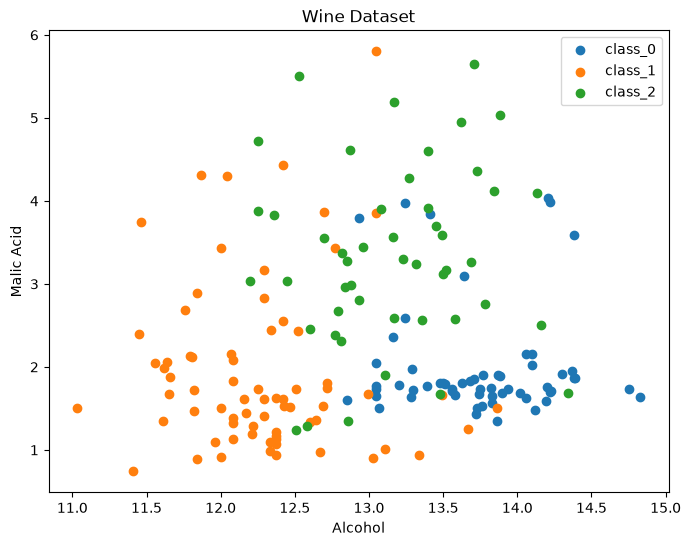

In [82]:
plt.figure(figsize=(8, 6))

for class_id in range(3):
    plt.scatter(
        X[y == class_id, 0],
        X[y == class_id, 1],
        label=wine.target_names[class_id]
    )

plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
plt.title("Wine Dataset")
plt.legend()
plt.show()

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (142, 13)
Shape of X_test: (36, 13)
Shape of y_train: (142,)
Shape of y_test: (36,)


In [84]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(X_train.shape)
print(y_train.shape)

torch.Size([142, 13])
torch.Size([142])


In [85]:
def entropy(y):
    classes, counts = torch.unique(
        y,
        return_counts=True
    )

    probabilities = counts.float() / len(y)

    entropy_value = -torch.sum(
        probabilities * torch.log2(probabilities)
    )

    return entropy_value

In [86]:
test_labels = torch.tensor([0, 0, 0, 1, 1, 2])

print("Entropy:", entropy(test_labels).item())

Entropy: 1.4591479301452637


In [87]:
pure = torch.tensor([1, 1, 1, 1])

print("Pure entropy:", entropy(pure).item())

Pure entropy: -0.0


In [88]:
def information_gain(parent, left, right):

    parent_entropy = entropy(parent)

    left_weight = len(left) / len(parent)
    right_weight = len(right) / len(parent)

    child_entropy = (
        left_weight * entropy(left)
        +
        right_weight * entropy(right)
    )

    gain = parent_entropy - child_entropy

    return gain

In [89]:
def split_dataset(X, y, feature_index, threshold):

    left_mask = X[:, feature_index] <= threshold
    right_mask = X[:, feature_index] > threshold

    X_left = X[left_mask]
    y_left = y[left_mask]

    X_right = X[right_mask]
    y_right = y[right_mask]

    return X_left, y_left, X_right, y_right

In [90]:
def best_split(X, y):

    best_gain = -1
    best_feature = None
    best_threshold = None

    n_features = X.shape[1]

    for feature_index in range(n_features):

        values = torch.unique(
            X[:, feature_index]
        )

        for threshold in values:

            left_mask = X[:, feature_index] <= threshold
            right_mask = X[:, feature_index] > threshold

            y_left = y[left_mask]
            y_right = y[right_mask]

            if len(y_left) == 0 or len(y_right) == 0:
                continue

            gain = information_gain(
                y,
                y_left,
                y_right
            )

            if gain > best_gain:
                best_gain = gain
                best_feature = feature_index
                best_threshold = threshold

    return (
        best_feature,
        best_threshold,
        best_gain
    )

In [91]:
feature, threshold, gain = best_split(
    X_train,
    y_train
)

print("Best feature:", feature)
print("Feature name:", wine.feature_names[feature])
print("Threshold:", threshold.item())
print("Information Gain:", gain.item())

Best feature: 11
Feature name: od280/od315_of_diluted_wines
Threshold: 2.1500000953674316
Information Gain: 0.7002233266830444


In [92]:
class Node:

    def __init__(
        self,
        feature=None,
        threshold=None,
        left=None,
        right=None,
        value=None
    ):
        self.feature = feature
        self.threshold = threshold

        self.left = left
        self.right = right

        self.value = value

In [93]:
def majority_class(y):

    counts = torch.bincount(y)

    return torch.argmax(counts).item()

In [94]:
def build_tree(
    X,
    y,
    depth=0,
    max_depth=5,
    min_samples_split=2
):

    # Stop if all samples belong to one class
    if len(torch.unique(y)) == 1:
        return Node(
            value=majority_class(y)
        )

    # Stop if maximum depth reached
    if depth >= max_depth:
        return Node(
            value=majority_class(y)
        )

    # Stop if too few samples
    if len(y) < min_samples_split:
        return Node(
            value=majority_class(y)
        )

    # Find best split
    feature, threshold, gain = best_split(X, y)

    # If no useful split exists
    if feature is None or gain <= 0:
        return Node(
            value=majority_class(y)
        )

    # Split dataset
    X_left, y_left, X_right, y_right = split_dataset(
        X,
        y,
        feature,
        threshold
    )

    # Recursively build children
    left_child = build_tree(
        X_left,
        y_left,
        depth + 1,
        max_depth,
        min_samples_split
    )

    right_child = build_tree(
        X_right,
        y_right,
        depth + 1,
        max_depth,
        min_samples_split
    )

    return Node(
        feature=feature,
        threshold=threshold,
        left=left_child,
        right=right_child
    )

In [95]:
tree = build_tree(
    X_train,
    y_train,
    max_depth=4
)

print("Decision Tree built successfully!")

Decision Tree built successfully!


In [96]:
def predict_one(node, x):

    # If leaf node
    if node.value is not None:
        return node.value

    if x[node.feature] <= node.threshold:
        return predict_one(
            node.left,
            x
        )

    else:
        return predict_one(
            node.right,
            x
        )

In [97]:
def predict_tree(tree, X):

    predictions = []

    for x in X:

        prediction = predict_one(
            tree,
            x
        )

        predictions.append(prediction)

    return torch.tensor(
        predictions,
        dtype=torch.long
    )

In [98]:
y_pred = predict_tree(
    tree,
    X_test
)

print("Predictions:")
print(y_pred)

print("\nActual:")
print(y_test)

Predictions:
tensor([0, 0, 1, 0, 1, 0, 1, 2, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 2,
        2, 2, 1, 1, 1, 0, 0, 1, 2, 0, 0, 0])

Actual:
tensor([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 2,
        2, 2, 1, 1, 1, 0, 0, 1, 2, 0, 0, 0])


In [99]:
accuracy = (
    y_pred == y_test
).float().mean()

print(
    f"Accuracy: {accuracy.item():.4f}"
)

Accuracy: 0.9167


In [100]:
cm = confusion_matrix(
    y_test.numpy(),
    y_pred.numpy()
)

print(cm)

[[14  0  0]
 [ 0 14  0]
 [ 1  2  5]]


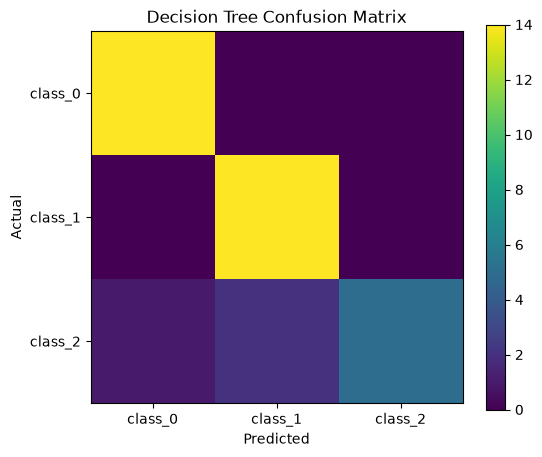

In [101]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    range(3),
    wine.target_names
)

plt.yticks(
    range(3),
    wine.target_names
)

plt.colorbar()

plt.show()

In [102]:
print(
    classification_report(
        y_test.numpy(),
        y_pred.numpy(),
        target_names=wine.target_names
    )
)

              precision    recall  f1-score   support

     class_0       0.93      1.00      0.97        14
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.62      0.77         8

    accuracy                           0.92        36
   macro avg       0.94      0.88      0.89        36
weighted avg       0.93      0.92      0.91        36



In [103]:
depths = [1, 2, 3, 4, 5, 6, 7]

train_accuracies = []
test_accuracies = []

for depth in depths:

    tree = build_tree(
        X_train,
        y_train,
        max_depth=depth
    )

    train_pred = predict_tree(
        tree,
        X_train
    )

    test_pred = predict_tree(
        tree,
        X_test
    )

    train_accuracy = (
        train_pred == y_train
    ).float().mean().item()

    test_accuracy = (
        test_pred == y_test
    ).float().mean().item()

    train_accuracies.append(
        train_accuracy
    )

    test_accuracies.append(
        test_accuracy
    )

    print(
        f"Depth={depth} | "
        f"Train={train_accuracy:.4f} | "
        f"Test={test_accuracy:.4f}"
    )

Depth=1 | Train=0.6338 | Test=0.5000
Depth=2 | Train=0.9437 | Test=0.9167
Depth=3 | Train=0.9930 | Test=0.9167
Depth=4 | Train=1.0000 | Test=0.9167
Depth=5 | Train=1.0000 | Test=0.9167
Depth=6 | Train=1.0000 | Test=0.9167
Depth=7 | Train=1.0000 | Test=0.9167


In [104]:
print(
    "Root feature:",
    wine.feature_names[tree.feature]
)

print(
    "Root threshold:",
    tree.threshold.item()
)

Root feature: od280/od315_of_diluted_wines
Root threshold: 2.1500000953674316
